# Brain plotting with NiSpace

NiSpace provides two standalone brain plotting functions from `nispace.plotting` that can be used independently of any colocalization analysis:

- `brainplot()` — renders parcellated DataFrames, NIfTI volumes, or GIfTI surface images on glass brains, anatomical slices, or inflated cortical surfaces.
- `view_surf()` — interactive 3D surface viewer (based on nilearn's `view_surf`).

These are the same functions that `nsp.plot_brain()` uses internally. Here we show how to use them directly, which is useful whenever you have brain maps to visualize outside of a NiSpace workflow — for example, for quality control, figure preparation, or just exploring a dataset.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nispace.plotting import brainplot, view_surf
from nispace.datasets import fetch_reference, fetch_example
from nispace.io import load_img

## `brainplot()` basics

The simplest use case: pass a NIfTI image and you get a plot. No parcellation needed.

(<Figure size 720x180 with 6 Axes>, [<Axes: >])

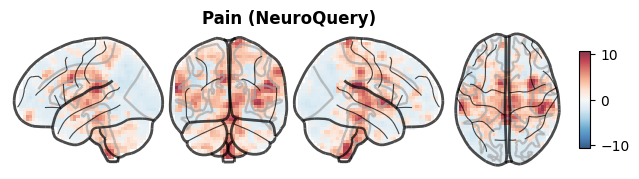

In [2]:
# load the pain map (a NIfTI image)
pain_map = load_img("neuroquery/pain.nii.gz")

# plot it — default rendering is glass brain for volumetric images
brainplot(pain_map, title="Pain (NeuroQuery)")

## Parcellated data

When you have parcellated data (a DataFrame or Series), pass the parcellation name or image alongside the data. NiSpace maps the parcel values back onto the brain.

INFO | 22/05/26 14:48:00 | nispace.datasets: Loading pet maps.
INFO | 22/05/26 14:48:00 | nispace.datasets: Loading integrated collection 'UniqueTracers' for dataset 'pet'.
INFO | 22/05/26 14:48:00 | nispace.datasets: Filtering maps by collection.
INFO | 22/05/26 14:48:00 | nispace.datasets: Loading data parcellated with 'Schaefer200'
INFO | 22/05/26 14:48:00 | nispace.core.parcellation: Building multi-space Parcellation for 'Schaefer200' from library.
INFO | 22/05/26 14:48:00 | nispace.core.parcellation: Available spaces: MNI152NLin2009cAsym, MNI152NLin6Asym, fsaverage, fsLR
INFO | 22/05/26 14:48:00 | nispace.core.parcellation: Parcellation 'Schaefer200': validation passed.
INFO | 22/05/26 14:48:00 | nispace.plotting: brainplot: threshold='auto' → 0.02822890877723694
INFO | 22/05/26 14:48:00 | nispace.core.parcellation: Lazy-loading parcellation image for space 'MNI152NLin2009cAsym'.
INFO | 22/05/26 14:48:00 | nispace.core.parcellation: Parcellation 'Schaefer200': active space set to 

(<Figure size 720x180 with 6 Axes>, [<Axes: >])

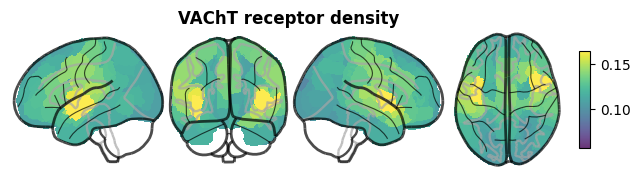

In [3]:
# fetch some PET maps, already parcellated
pet = fetch_reference("pet", parcellation="Schaefer200",
                      collection="UniqueTracers", print_references=False)

# plot a single map (select a Series by map-level name)
vacht = pet.loc[pet.index.get_level_values("map").str.contains("VAChT")].squeeze()

brainplot(vacht, parcellation="Schaefer200",
          title="VAChT receptor density", symmetric_cmap=False)

Opioid maps: ['target-MOR_tracer-carfentanil_n-204_dx-hc_pub-kantonen2020', 'target-KOR_tracer-ly2795050_n-28_dx-hc_pub-vijay2018', 'target-CB1_tracer-omar_n-77_dx-hc_pub-normandin2015']
INFO | 22/05/26 14:48:04 | nispace.core.parcellation: Building multi-space Parcellation for 'Schaefer200' from library.
INFO | 22/05/26 14:48:04 | nispace.core.parcellation: Available spaces: MNI152NLin2009cAsym, MNI152NLin6Asym, fsaverage, fsLR
INFO | 22/05/26 14:48:04 | nispace.core.parcellation: Parcellation 'Schaefer200': validation passed.
INFO | 22/05/26 14:48:04 | nispace.plotting: brainplot: threshold='auto' → 0.008912142366170883
INFO | 22/05/26 14:48:04 | nispace.core.parcellation: Lazy-loading parcellation image for space 'MNI152NLin2009cAsym'.
INFO | 22/05/26 14:48:04 | nispace.core.parcellation: Parcellation 'Schaefer200': active space set to 'MNI152NLin2009cAsym'.
INFO | 22/05/26 14:48:04 | nispace.plotting: brainplot: kind='glass', img_mode='None', surf_space='None', mni_space='MNI152NLi

(<Figure size 2160x180 with 18 Axes>, [<Axes: >, <Axes: >, <Axes: >])

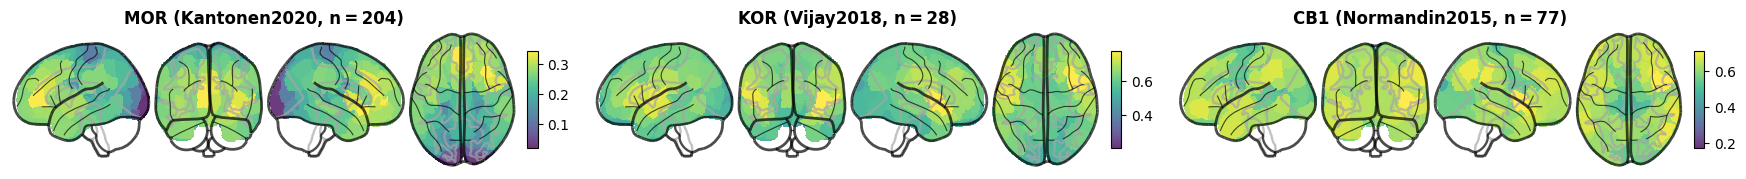

In [4]:
# plot multiple maps from a DataFrame
# select the opioid/endocannabinoid system maps
opioid_maps = pet.loc["Opiods/Endocannabinoids"]
print(f"Opioid maps: {list(opioid_maps.index)}")

brainplot(
    opioid_maps,
    parcellation="Schaefer200",
    symmetric_cmap=False,
    shared_colorscale=False,
    ncols=3
)

## Rendering modes

The `kind` argument controls how the brain is rendered.  

We currently have `"glass"`, `"slice"`, and `"surf"`.  
All these three options accept the `space` argument. For `"glass"` and `"slice"`, the two integrated MNI spaces are available (`"MNI152NLin2009cAsym"` and `"...6Asym"`); for `"surf"`, options are `"fsaverage"` and `"fsLR"` with their default meshes. Check the function reference for further information. 

These all use nilearn methods internally, but optimized for ease of use and very effective options to plot plot parcellated data. Also, every brain plot can easily be plotted into an axis as compared to only on figure level. If you are experienced with nilearn surface plotting, you might realize that the surfaces generate considerably faster. This is due to an internal tweak to nilearn's plot_surf function, improving array management.

### Glass brain plots

(<Figure size 720x180 with 6 Axes>, [<Axes: >])

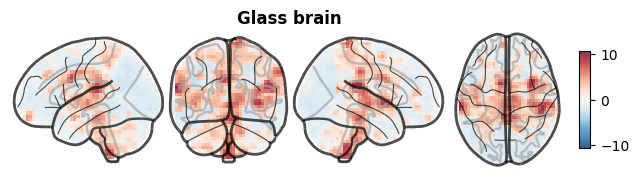

In [5]:
# glass brain (semi-transparent 3D volume)
brainplot(pain_map, kind="glass", title="Glass brain")

### Slice plots

(<Figure size 700x180 with 7 Axes>, [<Axes: >])

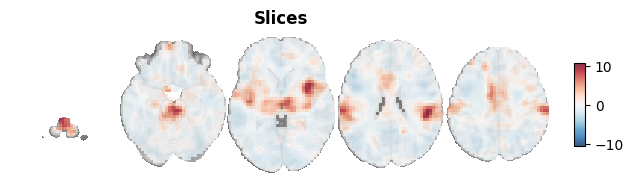

In [6]:
# anatomical slices
brainplot(pain_map, kind="slice", title="Slices")

### Surface plots

INFO | 22/05/26 14:48:19 | nispace.core.parcellation: Building multi-space Parcellation for 'Schaefer200' from library.
INFO | 22/05/26 14:48:19 | nispace.core.parcellation: Available spaces: MNI152NLin2009cAsym, MNI152NLin6Asym, fsaverage, fsLR
INFO | 22/05/26 14:48:19 | nispace.core.parcellation: Parcellation 'Schaefer200': validation passed.
INFO | 22/05/26 14:48:19 | nispace.plotting: brainplot: threshold='auto' → 0.02822890877723694
INFO | 22/05/26 14:48:19 | nispace.core.parcellation: Lazy-loading parcellation image for space 'fsaverage'.
INFO | 22/05/26 14:48:19 | nispace.core.parcellation: Parcellation 'Schaefer200': active space set to 'fsaverage'.
INFO | 22/05/26 14:48:19 | nispace.plotting: brainplot: kind='surface', img_mode='None', surf_space='fsaverage', mni_space='None', surf_mesh='inflated'


(<Figure size 800x220 with 2 Axes>, [<Axes: >])

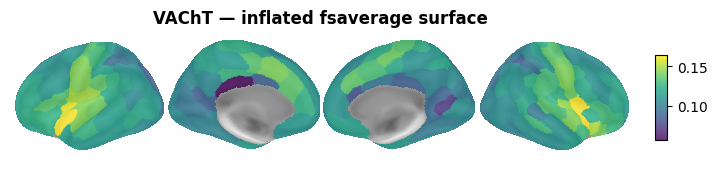

In [7]:
# inflated cortical surface (parcellated data), available: fsLR or fsaverage
brainplot(vacht, parcellation="Schaefer200",
          kind="surface", space="fsaverage", surf_mesh="inflated",
          symmetric_cmap=False, title="VAChT — inflated fsaverage surface")

INFO | 22/05/26 14:48:25 | nispace.core.parcellation: Building multi-space Parcellation for 'Schaefer200' from library.
INFO | 22/05/26 14:48:25 | nispace.core.parcellation: Available spaces: MNI152NLin2009cAsym, MNI152NLin6Asym, fsaverage, fsLR
INFO | 22/05/26 14:48:25 | nispace.core.parcellation: Parcellation 'Schaefer200': validation passed.
INFO | 22/05/26 14:48:25 | nispace.plotting: brainplot: threshold='auto' → 0.02822890877723694
INFO | 22/05/26 14:48:25 | nispace.core.parcellation: Lazy-loading parcellation image for space 'fsLR'.
INFO | 22/05/26 14:48:25 | nispace.core.parcellation: Parcellation 'Schaefer200': active space set to 'fsLR'.
INFO | 22/05/26 14:48:25 | nispace.plotting: brainplot: kind='surface', img_mode='None', surf_space='fsLR', mni_space='None', surf_mesh='midthickness'


(<Figure size 800x220 with 2 Axes>, [<Axes: >])

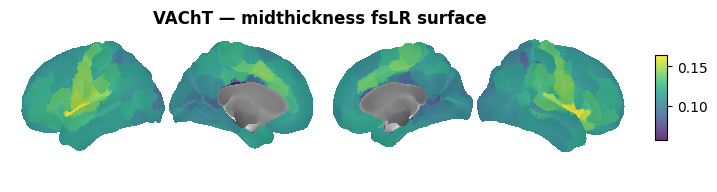

In [8]:
# fsLR midthickness surface
brainplot(vacht, parcellation="Schaefer200",
          kind="surface", space="fsLR", surf_mesh="midthickness",
          symmetric_cmap=False, title="VAChT — midthickness fsLR surface")

### Combined cortex-subcortex plots

TO BE IMPLEMENTED.

If you currently set `kind="combined"`, you will receive an `NotImplementedError`.  
In the future, we will have a special kind of plot that combined a surface at the top with a subcortical rendered volumetric, glassbrain, or slice representation at the bottom. This will work with integrated parcellations only and build specifically on the cortex-subcortex combination routine implemented in NiSpace.

## Colormap and scale options

(<Figure size 720x180 with 6 Axes>, [<Axes: >])

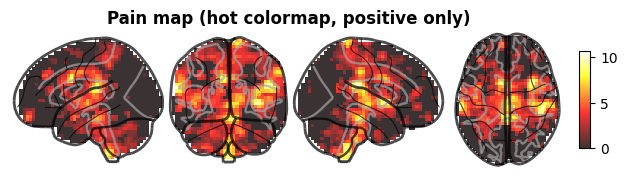

In [9]:
# custom colormap, threshold, and fixed scale
brainplot(
    pain_map,
    kind="glass",
    cmap="hot",
    symmetric_cmap=False,
    vmin=0,       # only show positive values
    threshold=0,  # explicitly threshold at 0
    title="Pain map (hot colormap, positive only)"
)

INFO | 22/05/26 14:48:30 | nispace.datasets: Loading example dataset: 'anorexianervosa', parcellated with: Schaefer200.
INFO | 22/05/26 14:48:30 | nispace.core.parcellation: Building multi-space Parcellation for 'Schaefer200' from library.
INFO | 22/05/26 14:48:30 | nispace.core.parcellation: Available spaces: MNI152NLin2009cAsym, MNI152NLin6Asym, fsaverage, fsLR
INFO | 22/05/26 14:48:30 | nispace.core.parcellation: Parcellation 'Schaefer200': validation passed.
INFO | 22/05/26 14:48:30 | nispace.plotting: brainplot: threshold='auto' → 0.13379129767417908
INFO | 22/05/26 14:48:30 | nispace.core.parcellation: Lazy-loading parcellation image for space 'MNI152NLin2009cAsym'.
INFO | 22/05/26 14:48:31 | nispace.core.parcellation: Parcellation 'Schaefer200': active space set to 'MNI152NLin2009cAsym'.
INFO | 22/05/26 14:48:31 | nispace.plotting: brainplot: kind='glass', img_mode='None', surf_space='None', mni_space='MNI152NLin2009cAsym', surf_mesh='inflated'


(<Figure size 1440x180 with 12 Axes>, [<Axes: >, <Axes: >])

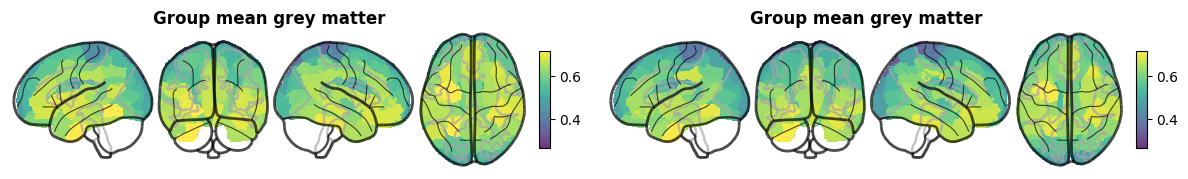

In [10]:
# shared color scale across multiple maps
# using the anorexia nervosa dataset for illustration (simulated — not for scientific use)
an_data = fetch_example("anorexianervosa", parcellation="Schaefer200")
groups = an_data.index.str.extract(r'(AN|HC)$')[0].values

# compute group means for a simple illustration
group_means = pd.DataFrame({
    "AN mean": an_data[groups == "AN"].mean(),
    "HC mean": an_data[groups == "HC"].mean()
}).T

brainplot(
    group_means,
    parcellation="Schaefer200",
    symmetric_cmap=False,
    shared_colorscale=True,  # same scale for both maps
    ncols=2,
    title="Group mean grey matter"
)

## Using `brainplot()` inside a larger figure

Pass `fig` and `axes` to embed the plot inside an existing matplotlib figure.

INFO | 22/05/26 14:48:45 | nispace.core.parcellation: Building multi-space Parcellation for 'Schaefer200' from library.
INFO | 22/05/26 14:48:45 | nispace.core.parcellation: Available spaces: MNI152NLin2009cAsym, MNI152NLin6Asym, fsaverage, fsLR
INFO | 22/05/26 14:48:45 | nispace.core.parcellation: Parcellation 'Schaefer200': validation passed.
INFO | 22/05/26 14:48:45 | nispace.plotting: brainplot: threshold='auto' → 0.02822890877723694
INFO | 22/05/26 14:48:45 | nispace.core.parcellation: Lazy-loading parcellation image for space 'MNI152NLin2009cAsym'.
INFO | 22/05/26 14:48:45 | nispace.core.parcellation: Parcellation 'Schaefer200': active space set to 'MNI152NLin2009cAsym'.
INFO | 22/05/26 14:48:45 | nispace.plotting: brainplot: kind='glass', img_mode='None', surf_space='None', mni_space='MNI152NLin2009cAsym', surf_mesh='inflated'
INFO | 22/05/26 14:48:50 | nispace.core.parcellation: Building multi-space Parcellation for 'Schaefer200' from library.
INFO | 22/05/26 14:48:50 | nispace

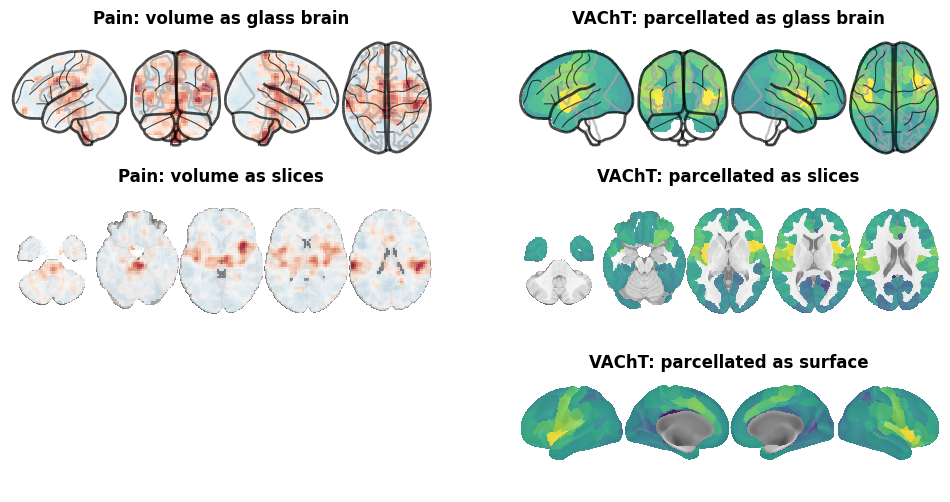

In [11]:
fig, axes = plt.subplots(3, 2, figsize=(12, 6))

# column 1: pain map
brainplot(pain_map, kind="glass", fig=fig, axes=axes[0,0],
          title="Pain: volume as glass brain", colorbar=False)
brainplot(pain_map, kind="slice", fig=fig, axes=axes[1,0], cut_coords=[-40, -20, 0, 10, 20],
          title="Pain: volume as slices", colorbar=False)
axes[2,0].set_axis_off()

# columns 2: parcellated VAChT 
brainplot(vacht, parcellation="Schaefer200", kind="glass",
          symmetric_cmap=False, fig=fig, axes=axes[0,1],
          title="VAChT: parcellated as glass brain", colorbar=False)
brainplot(vacht, parcellation="Schaefer200", kind="slice", cut_coords=[-40, -20, 0, 10, 20],
          symmetric_cmap=False, fig=fig, axes=axes[1,1],
          title="VAChT: parcellated as slices", colorbar=False)
brainplot(vacht, parcellation="Schaefer200", kind="surface",
          symmetric_cmap=False, fig=fig, axes=axes[2,1],
          title="VAChT: parcellated as surface", colorbar=False)

plt.show()

## Plot a parcellation via the Parcellation class

The `Parcellation` class also uses `brainplot` to generate plots.

/var/folders/6n/h4150p8d5gz5kbnqv5_406940000gp/T/ipykernel_21469/4004943157.py:5: DeprecationWarning: Starting in version 0.13, the default fetched mask will beAAL 3v2 instead.
  parc = Parcellation.from_path(fetch_atlas_aal().maps)


[fetch_atlas_aal] Dataset found in /Users/llotter/nilearn_data/aal_SPM12
INFO | 22/05/26 14:48:59 | nispace.core.parcellation: Building Parcellation from path / image.
INFO | 22/05/26 14:48:59 | nispace.core.parcellation: Parcellation space: 'mni152'.
INFO | 22/05/26 14:48:59 | nispace.core.parcellation: Parcellation 'None': validation passed.


(<Figure size 720x180 with 5 Axes>, [<Axes: >])

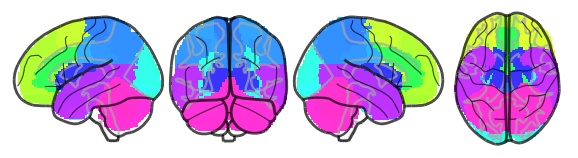

In [12]:
from nispace.core.parcellation import Parcellation
from nilearn.datasets import fetch_atlas_aal

# create the Parcellation object from a file path
parc = Parcellation.from_path(fetch_atlas_aal().maps)

# plot
parc.plot()

## Summary

**`brainplot()` key arguments:**

| Argument | What it does |
|----------|--------------|
| `data` | NIfTI image, GIfTI pair, DataFrame, or Series |
| `parcellation` | Required when `data` is tabular; a NiSpace name, file path, or image |
| `kind` | `"glass"`, `"slice"`, `"surface"`, `"combined"` |
| `cmap` | Any matplotlib colormap |
| `symmetric_cmap` | Zero-centered scale |
| `vmin`, `vmax` | Manual scale limits |
| `shared_colorscale` | Same scale across all maps in a DataFrame |
| `ncols` | Grid layout for multiple maps |
| `fig`, `axes` | Embed in existing matplotlib figure |

Next: [Notebook 9](intro9_workflows.ipynb) covers NiSpace's one-call workflow functions — the fastest way to run standard pipelines.